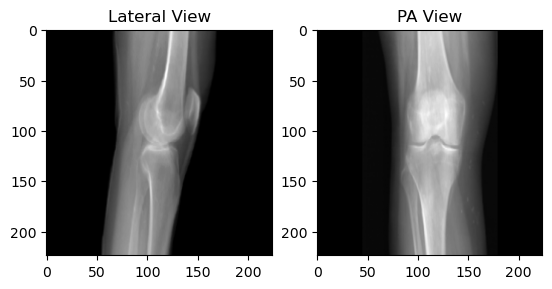

In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def center_pad_resize(image_path, target_size=224, pad_color=0):
    # Load in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.rotate(img, cv2.ROTATE_180)
    if img is None:
        raise FileNotFoundError(f"Image not found or unable to load: {image_path}")

    # Adaptive threshold for better segmentation
    _, thresh = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Select the largest contour
    if not contours:
        raise ValueError("No contours found.")
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box of the largest contour (assumed to be the knee)
    x, y, w, h = cv2.boundingRect(largest_contour)


    # Crop the knee region with some margin
    margin = 20
    x1 = max(x - margin, 0)
    y1 = max(y - margin, 0)
    x2 = min(x + w + margin, img.shape[1])
    y2 = min(y + h + margin, img.shape[0])
    cropped = img[y1:y2, x1:x2]

    # Resize with aspect ratio
    h_c, w_c = cropped.shape
    scale = target_size / max(h_c, w_c)
    resized = cv2.resize(cropped, (int(w_c * scale), int(h_c * scale)), interpolation=cv2.INTER_AREA)

    # Pad to 224x224
    h_r, w_r = resized.shape
    top = (target_size - h_r) // 2
    bottom = target_size - h_r - top
    left = (target_size - w_r) // 2
    right = target_size - w_r - left
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=pad_color)

    return padded

# Process both images
la_img = center_pad_resize('../data/processed/002/DRR/right/la.png')
pa_img = center_pad_resize('../data/processed/002/DRR/right/pa.png')

# Optional: visualize
plt.subplot(1, 2, 1)
plt.title("Lateral View")
plt.imshow(la_img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("PA View")
plt.imshow(pa_img, cmap='gray')
plt.show()
